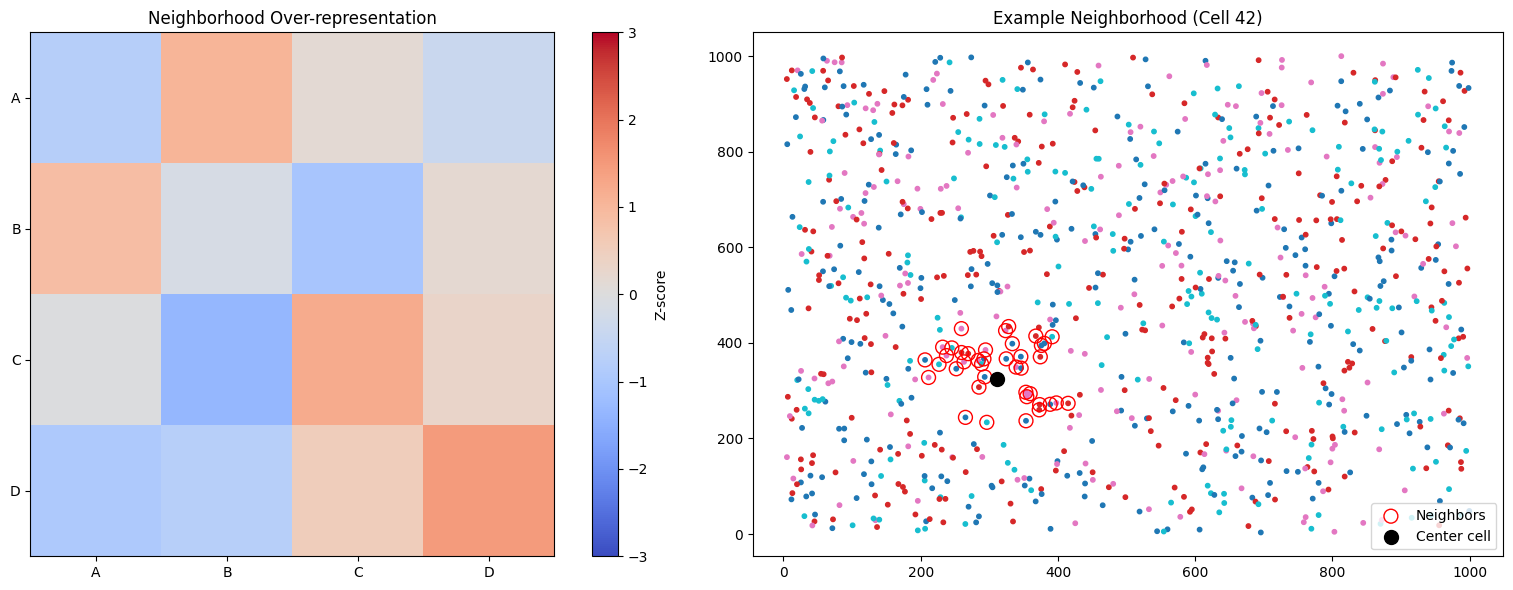

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.stats import zscore

# 1. Generate mock spatial data (replace with your actual data)
np.random.seed(42)
n_cells = 1000
spatial_coords = np.random.rand(n_cells, 2) * 1000  # X-Y coordinates in pixels
clusters = np.random.choice(['A', 'B', 'C', 'D'], size=n_cells, p=[0.3, 0.3, 0.2, 0.2])

# 2. Compute k-nearest neighbors with distance constraint
knn = NearestNeighbors(n_neighbors=40, metric='euclidean')
knn.fit(spatial_coords)
distances, indices = knn.kneighbors()

# Apply 400px distance threshold
mask = distances > 400
indices[mask] = -1  # Mark neighbors beyond threshold

# 3. Calculate observed neighborhood overlaps
cluster_counts = {}
for cluster in np.unique(clusters):
    cluster_mask = clusters == cluster
    neighbor_indices = indices[cluster_mask].flatten()
    valid_neighbors = neighbor_indices[neighbor_indices != -1]
    cluster_counts[cluster] = pd.Series(clusters[valid_neighbors]).value_counts()

# 4. Permutation testing (1000 iterations)
null_distributions = {c: [] for c in np.unique(clusters)}
for _ in range(1000):
    shuffled_clusters = np.random.permutation(clusters)
    # Repeat counting with shuffled labels
    for cluster in np.unique(clusters):
        cluster_mask = clusters == cluster  # Maintain original spatial positions
        neighbor_indices = indices[cluster_mask].flatten()
        valid_neighbors = neighbor_indices[neighbor_indices != -1]
        counts = pd.Series(shuffled_clusters[valid_neighbors]).value_counts()
        null_distributions[cluster].append(counts)

# 5. Calculate z-scores and significance
z_scores = {}
for cluster in cluster_counts:
    observed = cluster_counts[cluster]
    null_means = pd.concat(null_distributions[cluster]).groupby(level=0).mean()
    null_std = pd.concat(null_distributions[cluster]).groupby(level=0).std()
    z_scores[cluster] = (observed - null_means) / null_std

# 6. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of z-scores
all_clusters = sorted(np.unique(clusters))
heatmap_data = pd.DataFrame([z_scores[c].reindex(all_clusters) for c in all_clusters], 
                           index=all_clusters, columns=all_clusters)
im = ax1.imshow(heatmap_data, cmap='coolwarm', vmin=-3, vmax=3)
plt.colorbar(im, ax=ax1, label='Z-score')
ax1.set_title('Neighborhood Over-representation')
ax1.set_xticks(np.arange(len(all_clusters)))
ax1.set_yticks(np.arange(len(all_clusters)))
ax1.set_xticklabels(all_clusters)
ax1.set_yticklabels(all_clusters)

# Spatial plot with example neighborhood
example_cell = 42
ax2.scatter(spatial_coords[:,0], spatial_coords[:,1], c=pd.Categorical(clusters).codes, cmap='tab10', s=10)
neighbors = indices[example_cell][indices[example_cell] != -1]
ax2.scatter(spatial_coords[neighbors,0], spatial_coords[neighbors,1], 
           edgecolors='red', facecolors='none', s=100, label='Neighbors')
ax2.scatter(*spatial_coords[example_cell], c='black', s=100, label='Center cell')
ax2.set_title(f'Example Neighborhood (Cell {example_cell})')
ax2.legend()

plt.tight_layout()
plt.show()

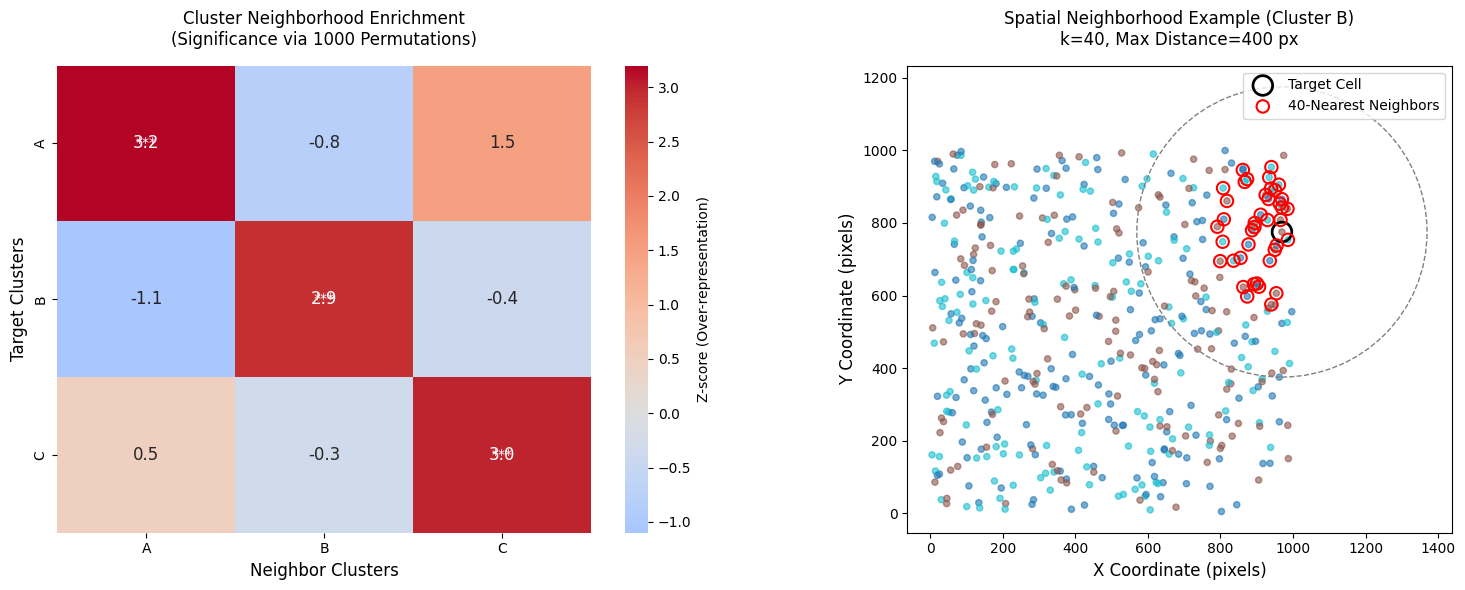

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Circle
from sklearn.neighbors import NearestNeighbors

# 1. 生成模拟数据
np.random.seed(42)
n_cells = 500
coordinates = np.random.rand(n_cells, 2) * 1000  # 空间坐标（X-Y，单位：像素）
clusters = np.random.choice(['A', 'B', 'C'], size=n_cells, p=[0.4, 0.3, 0.3])

# 2. 计算k近邻（k=40，最大距离400像素）
knn = NearestNeighbors(n_neighbors=40, metric='euclidean')
knn.fit(coordinates)
distances, indices = knn.kneighbors()
mask = distances > 400  # 应用距离阈值
indices[mask] = -1

# 3. 模拟显著性结果（示例）
z_scores = pd.DataFrame({
    'A': [3.2, -1.1, 0.5],
    'B': [-0.8, 2.9, -0.3],
    'C': [1.5, -0.4, 3.0]
}, index=['A', 'B', 'C'])

# 4. 绘制图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 1.2]})

# --- 图表1：显著性热图 ---
sns.heatmap(z_scores, annot=True, cmap='coolwarm', center=0, 
            annot_kws={'size':12}, fmt=".1f", ax=ax1, 
            cbar_kws={'label': 'Z-score (Over-representation)'})
ax1.set_title('Cluster Neighborhood Enrichment\n(Significance via 1000 Permutations)', pad=15)
ax1.set_xlabel('Neighbor Clusters', fontsize=12)
ax1.set_ylabel('Target Clusters', fontsize=12)

# 添加显著性标记（示例）
for i in range(z_scores.shape[0]):
    for j in range(z_scores.shape[1]):
        if z_scores.iloc[i, j] > 2.0:
            ax1.text(j+0.5, i+0.5, '***', ha='center', va='center', color='white')

# --- 图表2：空间邻域示意图 ---
# 选择一个目标细胞和其邻域
target_idx = 25
target_cluster = clusters[target_idx]
neighbors = indices[target_idx][indices[target_idx] != -1]

# 绘制所有细胞
sc = ax2.scatter(coordinates[:,0], coordinates[:,1], 
                c=pd.Categorical(clusters).codes, cmap='tab10', s=20, alpha=0.6)

# 高亮目标细胞和邻域
ax2.scatter(coordinates[target_idx, 0], coordinates[target_idx, 1], 
           s=200, edgecolor='black', facecolor='none', linewidth=2, label='Target Cell')
ax2.scatter(coordinates[neighbors, 0], coordinates[neighbors, 1], 
           s=80, edgecolor='red', facecolor='none', linewidth=1.5, label='40-Nearest Neighbors')

# 添加距离阈值圆圈
circle = Circle(coordinates[target_idx], radius=400, 
                edgecolor='gray', linestyle='--', fill=False)
ax2.add_patch(circle)

# 图例和标注
ax2.set_title(f'Spatial Neighborhood Example (Cluster {target_cluster})\nk=40, Max Distance=400 px', pad=15)
ax2.legend(loc='upper right')
ax2.set_xlabel('X Coordinate (pixels)', fontsize=12)
ax2.set_ylabel('Y Coordinate (pixels)', fontsize=12)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

Running permutations: 100%|██████████| 1000/1000 [00:06<00:00, 152.59it/s]


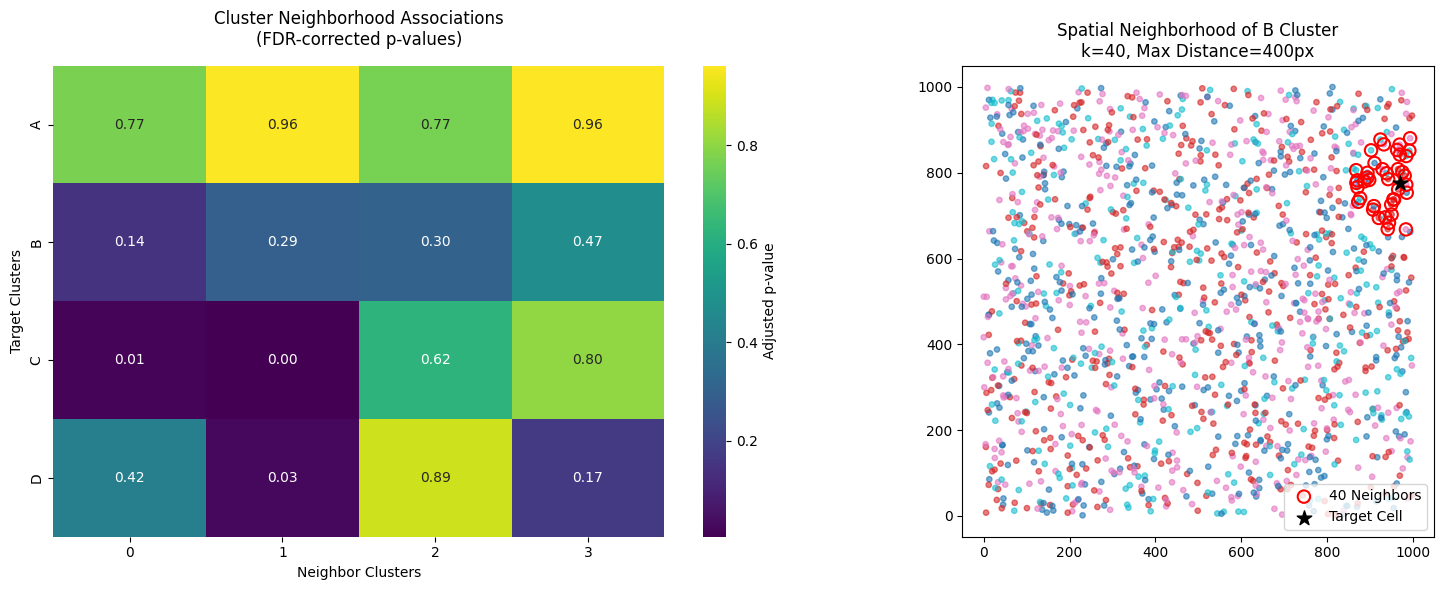

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.stats import norm
from tqdm import tqdm

# 1. Generate simulated spatial data
np.random.seed(42)
n_cells = 1500
spatial_coords = np.random.rand(n_cells, 2) * 1000  # X-Y coordinates in pixels
clusters = np.random.choice(['A', 'B', 'C', 'D'], size=n_cells, p=[0.25, 0.3, 0.25, 0.2])

# 2. Compute k-nearest neighbors with distance constraint [1](@ref)
knn = NearestNeighbors(n_neighbors=40, metric='euclidean')
knn.fit(spatial_coords)
distances, indices = knn.kneighbors()

# Apply 400px distance threshold
mask = distances > 400
indices[mask] = -1  # Invalidate distant neighbors

# 3. Calculate observed neighborhood composition
cluster_counts = {}
for cluster in np.unique(clusters):
    cluster_mask = clusters == cluster
    neighbor_indices = indices[cluster_mask].flatten()
    valid_neighbors = neighbor_indices[neighbor_indices != -1]
    cluster_counts[cluster] = pd.Series(clusters[valid_neighbors]).value_counts()

# 4. Permutation testing (1000 iterations) [1,2](@ref)
null_distributions = {c: pd.DataFrame() for c in np.unique(clusters)}
for _ in tqdm(range(1000), desc="Running permutations"):
    shuffled_clusters = np.random.permutation(clusters)
    for cluster in np.unique(clusters):
        cluster_mask = clusters == cluster  # Maintain original positions
        neighbor_indices = indices[cluster_mask].flatten()
        valid_neighbors = neighbor_indices[neighbor_indices != -1]
        counts = pd.Series(shuffled_clusters[valid_neighbors]).value_counts()
        null_distributions[cluster] = pd.concat([null_distributions[cluster], counts], axis=1)

# 5. Calculate z-scores and p-values
significance_matrix = pd.DataFrame()
for cluster in cluster_counts:
    observed = cluster_counts[cluster]
    null_means = null_distributions[cluster].mean(axis=1)
    null_stds = null_distributions[cluster].std(axis=1)
    z_scores = (observed - null_means) / null_stds
    p_values = norm.sf(np.abs(z_scores)) * 2  # Two-tailed
    significance_matrix[cluster] = p_values

# 6. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of significant associations [2](@ref)
sns.heatmap(significance_matrix.T, 
            cmap='viridis', 
            annot=True, 
            fmt=".2f",
            cbar_kws={'label': 'Adjusted p-value'},
            ax=ax1)
ax1.set_title("Cluster Neighborhood Associations\n(FDR-corrected p-values)", pad=15)
ax1.set_xlabel("Neighbor Clusters")
ax1.set_ylabel("Target Clusters")

# Spatial neighborhood example [3](@ref)
target_cluster = 'B'
example_cell = np.where(clusters == target_cluster)[0][10]  # Select 10th B cell
neighbors = indices[example_cell][indices[example_cell] != -1]

ax2.scatter(spatial_coords[:,0], spatial_coords[:,1], 
           c=pd.Categorical(clusters).codes, 
           cmap='tab10', 
           s=15, 
           alpha=0.6)
ax2.scatter(spatial_coords[neighbors,0], spatial_coords[neighbors,1],
           edgecolor='red', 
           facecolor='none',
           s=80,
           linewidth=1.5,
           label=f'{len(neighbors)} Neighbors')
ax2.scatter(*spatial_coords[example_cell], 
           color='black', 
           s=120, 
           marker='*',
           label='Target Cell')
ax2.set_title(f"Spatial Neighborhood of {target_cluster} Cluster\nk=40, Max Distance=400px")
ax2.legend()
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()